## Автоматизация обработки данных (создание витрин данных)

## Описание проекта

Такси. Каждый день компания обрабатывает миллионы поездок, оплаченных разными способами. Чтобы продуктовая команда регулярно получала актуальные данные о выручке и поведении пассажиров, необходимо настроить автоматическую обработку данных.

**Цель:** разработать автоматизированный пайплайн в Airflow для ежедневной агрегации ключевых метрик такси.

**Задачи** - построить витрину данных с агрегацией о поездках по каждому способу оплаты. Для этого нужно написать PySpark-скрипт, который рассчитает ключевые показатели: количество поездок, среднюю стоимость поездки, средние чаевые и суммарную выручку по каждому типу оплаты.

Чтобы процесс был полностью автоматическим и не зависел от ручных запусков, необходимо создать DAG в Airflow. Этот DAG должен ежедневно:

* проверять наличие новых файлов с данными;

* запускать Spark-задачу;

* формировать обновлённую итоговую таблицу.

## Описание данных

Таблица `taxi_data` содержит данные об активности пользователей и состоит из следующих полей:

* `taxi_id` — идентификатор водителя;

* `trip_start_timestamp` — время начала поездки;

* `trip_end_timestamp` — время окончания поездки;

* `trip_seconds` — длительность поездки в секундах;

* `trip_miles` — дистанция поездки;

* `fare` — стоимость поездки;

* `tips` — размер чаевых;

* `trip_total` — общая стоимость поездки: стоимость поездки + чаевые + комиссия;

* `payment_type` — способ оплаты.

## Действия

1. Нобходимо написать Spark-скрипт, который будет обрабатывать данные о поездках и агрегировать показатели по способам оплаты `payment_type`. Понадобится рассчитать несколько показателей:

* количество поездок, которое показывает общий спрос и загрузку сервиса;
* среднюю стоимость `fare`, которое отражает уровень среднего чека поездки;
* средние чаевые `tips` — индикатор удовлетворённости клиентов и мотивации водителей;
* суммарную выручку `trip_total` — ключевой показатель дохода компании.

Все результаты должны собираться в одну итоговую таблицу `taxi_payment_summary`. После этого таблицу нужно записать в ClickHouse с помощью JDBC-драйвера.

2. Далее необходимо настроить DAG в Airflow. DAG должен запускаться ежедневно. Перед запуском он проверяет наличие файла с данными за нужную дату в S3-хранилище и только после появления файла запускает Spark-задачу.

## Шаг 1. Настройка Spark-агрегации

Данные хранятся в формате Parquet, поэтому для чтения используем метод `spark.read.parquet()`. 

Сгруппируем данные по полю `payment_type` и рассчитаем четыре показателя:

* количество поездок — `count(*)`;
* среднюю стоимость — `avg(...)`;
* средние чаевые — `avg(...)`;
* суммарную выручку — `sum(...)`.

Получилась витрина для анализа информации по каждому способу оплаты. 

In [ ]:
# filename=my_spark_job.py

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Создаём Spark-сессию
spark = (
    SparkSession.builder.appName("myAggregateTest")
    .config("fs.s3a.endpoint", "storage.yandexcloud.net")
    .config("spark.dynamicAllocation.enabled", "false")
    .config("spark.executor.instances", "1")
    .config("spark.executor.cores", "1")
    .config("spark.executor.memory", "1g")
    .config("spark.driver.memory", "1g")
    .getOrCreate()
)
# Параметры подключения к ClickHouse
jdbcPort = 8443
jdbcHostname = "rc1a-3jouval14nne7aun.mdb.yandexcloud.net"
username = "da_20..."
jdbcDatabase = "playground_" + username
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"

# Считываем Parquet-файл
taxi_data_df = spark.read.parquet("s3a://da-pluss-dags/project_04/taxi_data.parquet")

# Агрегируем и рассчитываем метрики
result_df = taxi_data_df.groupBy("payment_type") \
    .agg(
        F.count("*").alias("total_count"),
        F.avg(F.col("fare")).alias("avg_fare"),
        F.avg(F.col("tips")).alias("avg_tips"),
        F.sum(F.col("trip_total")).alias("sum_trip_total")
    )

# Записываем результат в таблицу ClickHouse
result_df.write.format("jdbc") \
    .option("url", jdbcUrl) \
    .option("user", username) \
    .option("password", "b1a...") \
    .option("dbtable", "taxi_payment_summary") \
    .option("createTableOptions", "ENGINE=MergeTree() ORDER BY payment_type") \
    .mode("overwrite") \ # перезаписываем данные
    .save()

## Шаг 2. Настройка DAG

В DAG используем `S3KeySensor`, чтобы дождаться появления файла в S3. После этого запускаем `DataprocCreatePysparkJobOperator`.

In [ ]:
# filename=taxi_payment_dag.py

from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

DAG_ID = "taxi_payment_aggregate"

with DAG(
    dag_id=DAG_ID,
    start_date=datetime(2026, 1, 1),
    schedule_interval="@daily",
    catchup=False,
    tags=["taxi"]
) as dag:
    # 1) Ждём появления файла в S3
    wait_for_input = S3KeySensor(
        task_id='wait_for_s3',
        bucket_key="project_04/taxi_data.parquet",  
        bucket_name="da-plus-dags",
        wildcard_match=False,
        aws_conn_id='s3',
        poke_interval=300,
        timeout=3600,
        mode='poke'
    )

    # 2) Запускаем PySpark-задание на кластере Dataproc
    user = "da_20..."
    run_pyspark = DataprocCreatePysparkJobOperator(
        name="create_taxi_summary",       
        task_id="create_pyspark_job",
        cluster_id="c9q4134h5vi546h1e148",
        main_python_file_uri=f"s3a://da-pluss-dags/{user}/jobs/my_spark_job.py"
    )

    # 3) Зависимости
    wait_for_input >> run_pyspark


## Шаг 3. Результат DAG с помощью Airflow


**Результат**

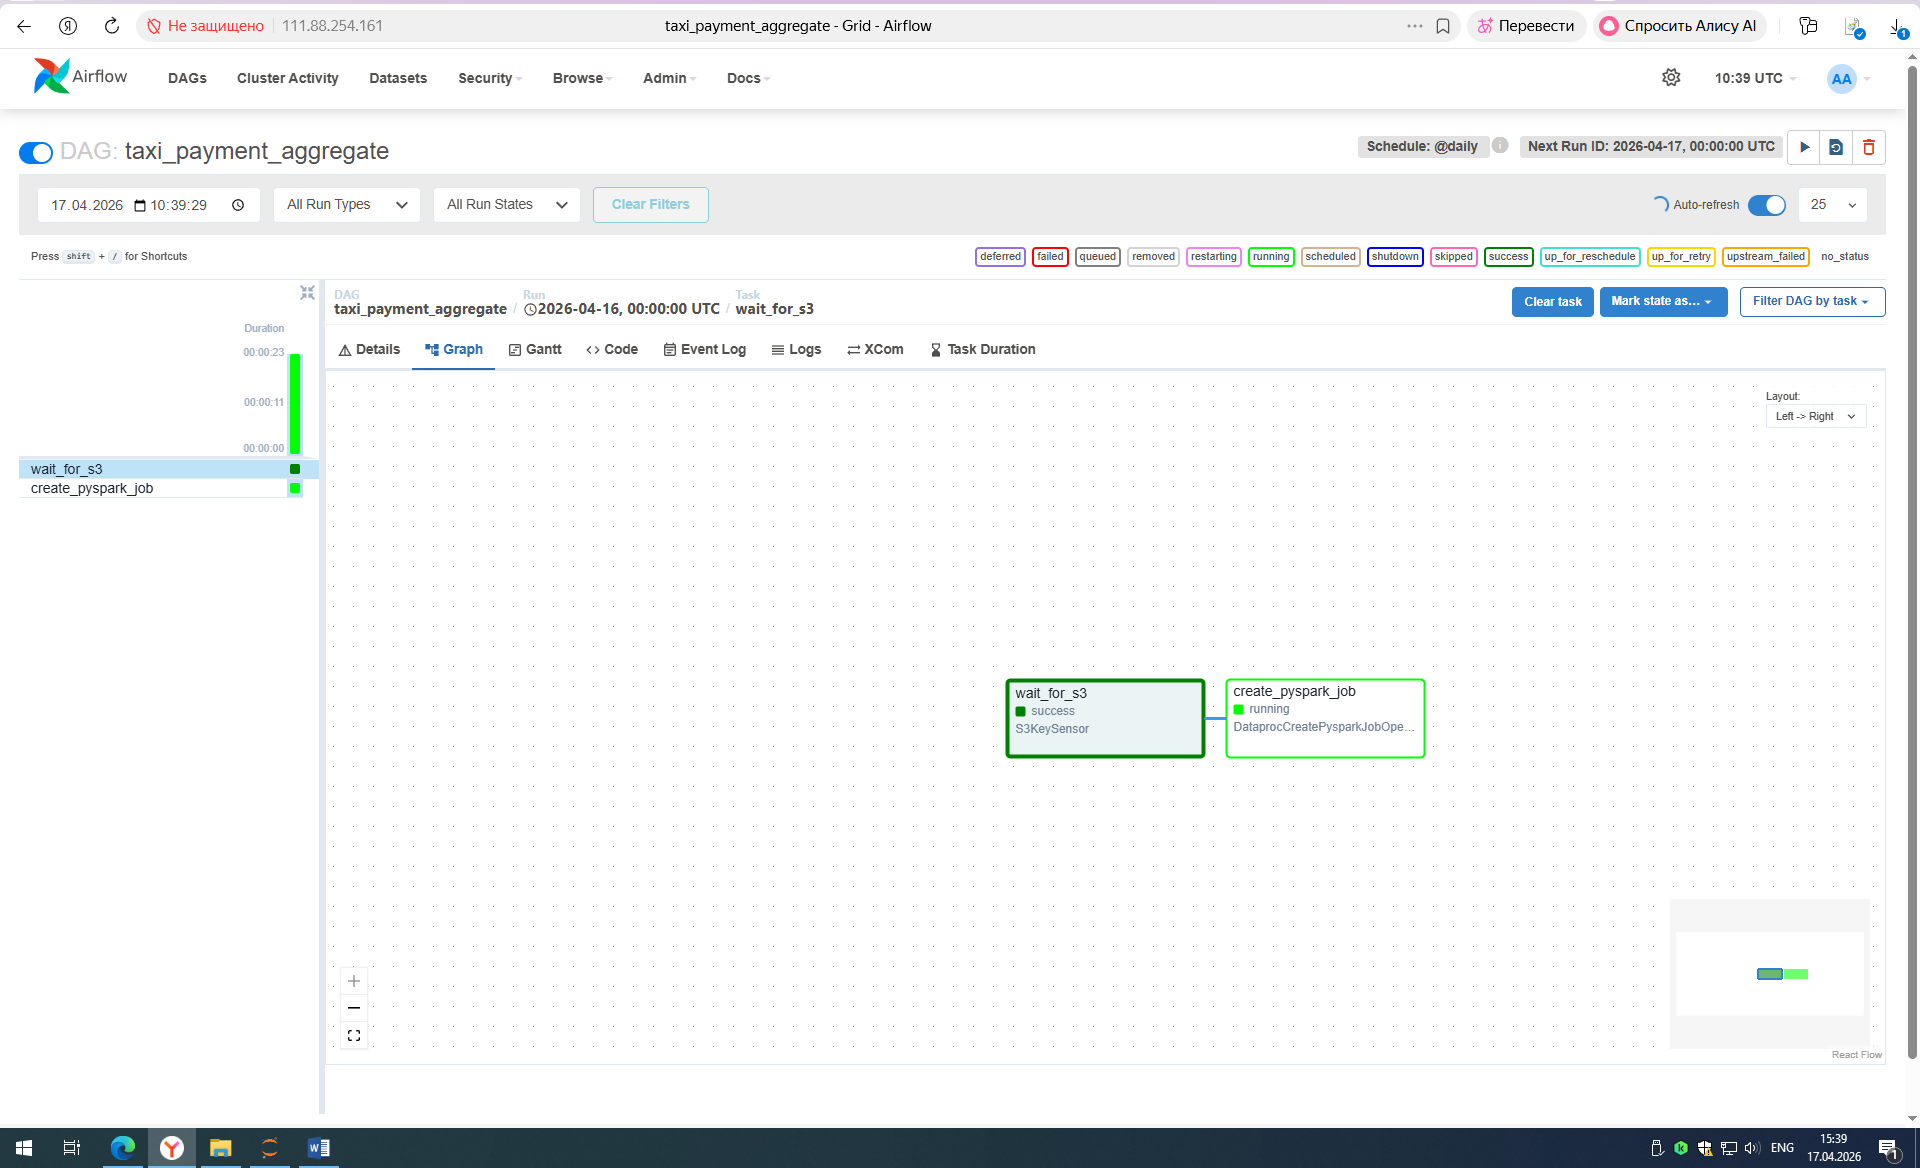

**Проверяем таблицу в ClickHouse**

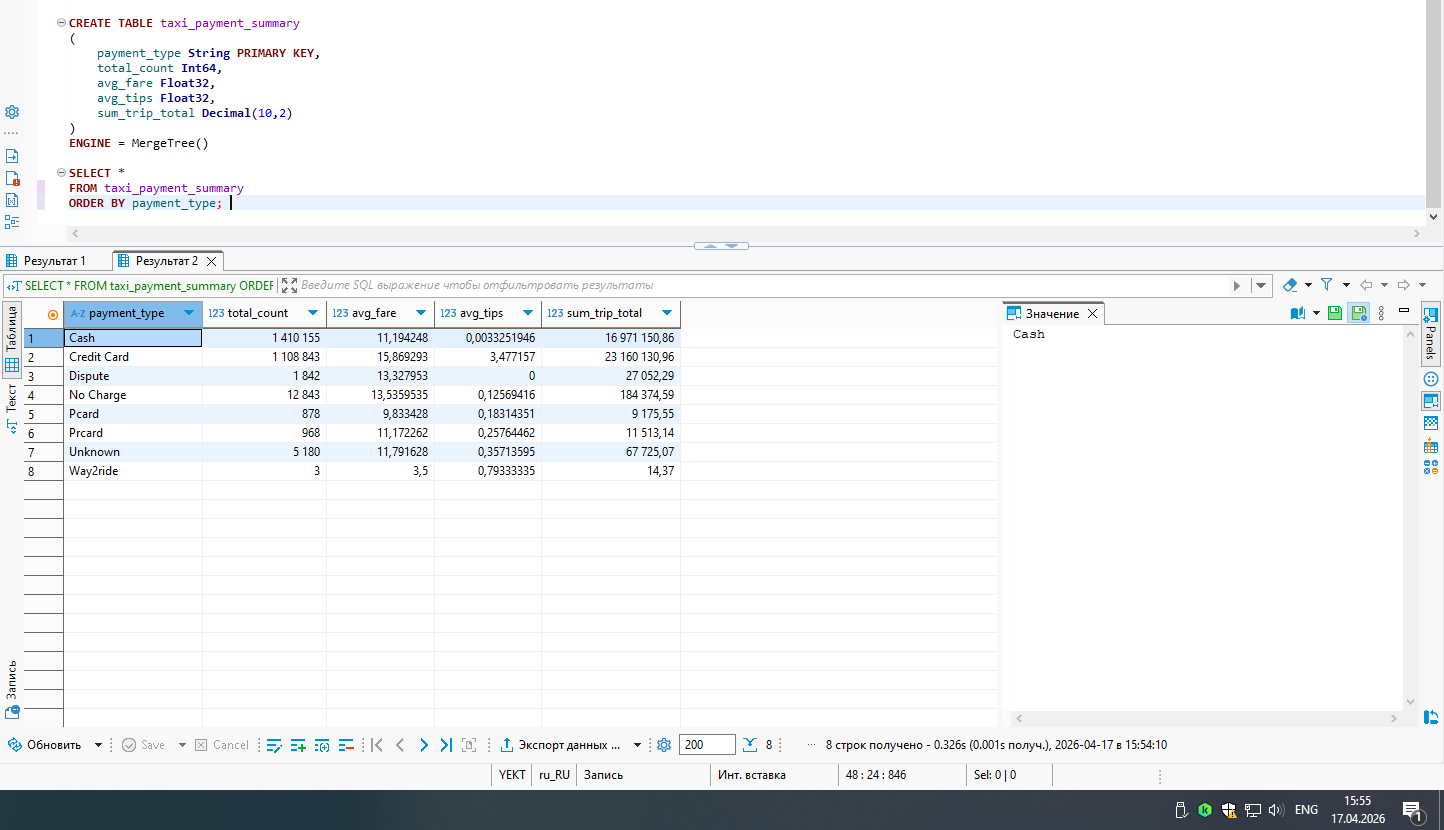